In [1]:
from ultralytics import YOLO

import cv2
import json
import timm
import torch
import numpy as np

from pathlib import Path
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

c:\Computer Vision Project\Supermarket shelves\Supermarket shelves\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(DEVICE)

cpu


In [3]:
detector = YOLO("models/best.pt")

In [4]:
checkpoint = torch.load(
    "models/best_model.pth",
    map_location=DEVICE
)

In [5]:
classifier = timm.create_model(
    checkpoint["architecture"],
    pretrained=False,
    num_classes=len(checkpoint["class_names"])
)

classifier.load_state_dict(
    checkpoint["model_state_dict"]
)

classifier.to(DEVICE)

classifier.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa)

In [6]:
transform = A.Compose([

    A.Resize(
        checkpoint["image_size"],
        checkpoint["image_size"]
    ),

    A.Normalize(),

    ToTensorV2()

])

In [7]:
softmax = torch.nn.Softmax(dim=1)

In [8]:
CONFIDENCE = 0.25

ROW_THRESHOLD = 25

OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(exist_ok=True)

(OUTPUT_DIR/"crops").mkdir(exist_ok=True)

(OUTPUT_DIR/"debug").mkdir(exist_ok=True)

In [9]:
def classify(crop):

    rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    image = transform(
        image=rgb
    )["image"]

    image = image.unsqueeze(0)

    image = image.to(DEVICE)

    with torch.no_grad():

        outputs = classifier(image)

        probs = softmax(outputs)

        confidence,index = torch.max(
            probs,
            1
        )

    return (

        checkpoint["class_names"][
            index.item()
        ],

        confidence.item()

    )

In [10]:
def detect(image_path):

    results = detector.predict(

        source=image_path,

        conf=CONFIDENCE,

        save=False,

        verbose=False

    )

    return results[0]

In [11]:
def extract_detections(image_path):

    image = cv2.imread(image_path)

    result = detect(image_path)

    detections = []

    crop_number = 0

    for box in result.boxes:

        cls = int(box.cls[0])

        label = detector.names[cls]

        confidence = float(box.conf[0])

        x1,y1,x2,y2 = map(
            int,
            box.xyxy[0]
        )

        detection = {

            "type":label,

            "bbox":[
                x1,
                y1,
                x2,
                y2
            ],

            "confidence":confidence

        }

        if label=="product":

            crop = image[
                y1:y2,
                x1:x2
            ]

            product_name,score = classify(crop)

            crop_name = f"{crop_number}.jpg"

            cv2.imwrite(

                str(
                    OUTPUT_DIR/
                    "crops"/
                    crop_name
                ),

                crop

            )

            detection["product_name"] = product_name

            detection["classification_confidence"] = score

            crop_number += 1

        detections.append(
            detection
        )

    return detections

In [12]:
detections = extract_detections(
    "coldrinks dataset/18.jpg"
)
# detections = extract_detections(
#     "coldrinks dataset/18.jpg"
# )
print(json.dumps(
    detections,
    indent=4
))

[
    {
        "type": "product",
        "bbox": [
            125,
            195,
            171,
            368
        ],
        "confidence": 0.9138137102127075,
        "product_name": "Sprite",
        "classification_confidence": 0.9999991655349731
    },
    {
        "type": "product",
        "bbox": [
            379,
            418,
            431,
            590
        ],
        "confidence": 0.9114600419998169,
        "product_name": "Sprite",
        "classification_confidence": 0.9659756422042847
    },
    {
        "type": "product",
        "bbox": [
            546,
            420,
            595,
            593
        ],
        "confidence": 0.9030597805976868,
        "product_name": "Coca Cola",
        "classification_confidence": 0.9999969005584717
    },
    {
        "type": "product",
        "bbox": [
            710,
            425,
            762,
            601
        ],
        "confidence": 0.900847852230072,
        "product_name

In [13]:
def draw_detections(image_path,detections):

    image = cv2.imread(image_path)

    for d in detections:

        x1,y1,x2,y2 = d["bbox"]

        if d["type"]=="product":

            text = d["product_name"]

            color = (0,255,0)

        else:

            text = "EMPTY"

            color = (0,0,255)

        cv2.rectangle(

            image,

            (x1,y1),

            (x2,y2),

            color,

            2

        )

        cv2.putText(

            image,

            text,

            (x1,y1-8),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.6,

            color,

            2

        )

    cv2.imwrite(

        str(
            OUTPUT_DIR/
            "debug"/
            "debug.jpg"
        ),

        image
    )

In [14]:
draw_detections(
    "coldrinks dataset/18.jpg",
    detections
)

In [15]:
def add_geometry(detections):

    for d in detections:

        x1,y1,x2,y2 = d["bbox"]

        d["center_x"] = (x1+x2)/2
        d["center_y"] = (y1+y2)/2

        d["bottom"] = y2

        d["width"] = x2-x1
        d["height"] = y2-y1

    return detections

In [16]:
detections = add_geometry(detections)

In [17]:
def assign_rows(detections, threshold=25):

    detections = sorted(
        detections,
        key=lambda d:d["bottom"]
    )

    rows=[]

    for det in detections:

        assigned=False

        for row in rows:

            if abs(det["bottom"]-row["bottom"])<threshold:

                row["objects"].append(det)

                row["bottom"]=(
                    row["bottom"]+
                    det["bottom"]
                )/2

                assigned=True

                break

        if not assigned:

            rows.append({

                "bottom":det["bottom"],

                "objects":[det]

            })

    return rows

In [18]:
rows = assign_rows(detections)

In [19]:
for i,row in enumerate(rows,start=1):

    for obj in row["objects"]:

        obj["row"]=i

In [20]:
for row in rows:

    row["objects"] = sorted(

        row["objects"],

        key=lambda d:d["center_x"]

    )

In [21]:
for row in rows:

    for position,obj in enumerate(

        row["objects"],

        start=1

    ):

        obj["position"]=position

In [22]:
slots=[]

slot_id=1

for row in rows:

    for obj in row["objects"]:

        slot={

            "slot_id":slot_id,

            "row":obj["row"],

            "position":obj["position"],

            "center":[

                obj["center_x"],

                obj["center_y"]

            ],

            "bbox":obj["bbox"],

            "expected_type":obj["type"]

        }

        if obj["type"]=="product":

            slot["expected_product"]=obj["product_name"]

        else:

            slot["expected_product"]=None

        slots.append(slot)

        slot_id+=1

In [23]:
reference_json={

    "image":"reference_1.jpg",

    "total_slots":len(slots),

    "slots":slots

}

In [24]:
with open(

    OUTPUT_DIR/

    "reference.json",

    "w"

) as f:

    json.dump(

        reference_json,

        f,

        indent=4
    )

In [25]:
print(

json.dumps(

reference_json,

indent=4

)

)

{
    "image": "reference_1.jpg",
    "total_slots": 72,
    "slots": [
        {
            "slot_id": 1,
            "row": 1,
            "position": 1,
            "center": [
                21.5,
                85.0
            ],
            "bbox": [
                1,
                19,
                42,
                151
            ],
            "expected_type": "product",
            "expected_product": "Sprite"
        },
        {
            "slot_id": 2,
            "row": 1,
            "position": 2,
            "center": [
                63.5,
                84.5
            ],
            "bbox": [
                45,
                19,
                82,
                150
            ],
            "expected_type": "product",
            "expected_product": "Thumbs up"
        },
        {
            "slot_id": 3,
            "row": 1,
            "position": 3,
            "center": [
                104.5,
                82.5
            ],
      

In [26]:
def draw_rows(image_path,detections):

    image=cv2.imread(image_path)

    for d in detections:

        x1,y1,x2,y2=d["bbox"]

        text=f"R{d['row']} P{d['position']}"

        cv2.putText(

            image,

            text,

            (x1,y2+18),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.5,

            (255,0,0),

            2

        )

    cv2.imwrite(

        str(

            OUTPUT_DIR/

            "debug"/

            "rows.jpg"

        ),

        image
    )

In [27]:
draw_rows(
    "reference_images/reference_1.jpg",
    detections
)

In [28]:
def draw_slot_ids(image_path,slots):

    image=cv2.imread(image_path)

    for slot in slots:

        x1,y1,x2,y2=slot["bbox"]

        cv2.putText(

            image,

            str(slot["slot_id"]),

            (x1,y1-8),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.7,

            (0,0,255),

            2

        )

    cv2.imwrite(

        str(

            OUTPUT_DIR/

            "debug"/

            "slots.jpg"

        ),

        image
    )

In [29]:
draw_slot_ids(
    "reference_images/reference_1.jpg",
    slots
)

In [30]:
CURRENT_IMAGE = "current_images/current_1.jpg"

current_detections = extract_detections(CURRENT_IMAGE)

current_detections = add_geometry(current_detections)

rows = assign_rows(current_detections)

for i, row in enumerate(rows, start=1):

    for obj in row["objects"]:

        obj["row"] = i

for row in rows:

    row["objects"] = sorted(
        row["objects"],
        key=lambda x: x["center_x"]
    )

for row in rows:

    for position, obj in enumerate(row["objects"], start=1):

        obj["position"] = position

In [33]:
import json

with open("outputs/reference.json") as f:
    reference = json.load(f)

reference_slots = reference["slots"]

In [38]:
current_slots = []

slot_id = 1

for row in rows:

    for obj in row["objects"]:

        current_slots.append({

            "slot_id": slot_id,

            "row": obj["row"],

            "position": obj["position"],

            "center": [
                obj["center_x"],
                obj["center_y"]
            ],

            "bbox": obj["bbox"],

            "product": obj["product_name"]

        })

        slot_id += 1

print(len(current_slots))

77


In [39]:
from torchvision.ops import nms
import torch

In [44]:
import numpy as np

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)

    inter = inter_w * inter_h

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    if union == 0:
        return 0

    return inter / union


def remove_duplicate_slots(slots, iou_threshold=0.7):

    # Highest confidence first
    slots = sorted(
        slots,
        key=lambda x: x.get("confidence", 1.0),
        reverse=True
    )

    keep = []

    while slots:

        best = slots.pop(0)
        keep.append(best)

        remaining = []

        for s in slots:

            iou = compute_iou(best["bbox"], s["bbox"])

            if iou < iou_threshold:
                remaining.append(s)

        slots = remaining

    return keep


reference_slots = remove_duplicate_slots(reference_slots)
current_slots = remove_duplicate_slots(current_slots)

print("Reference:", len(reference_slots))
print("Current:", len(current_slots))

Reference: 67
Current: 67


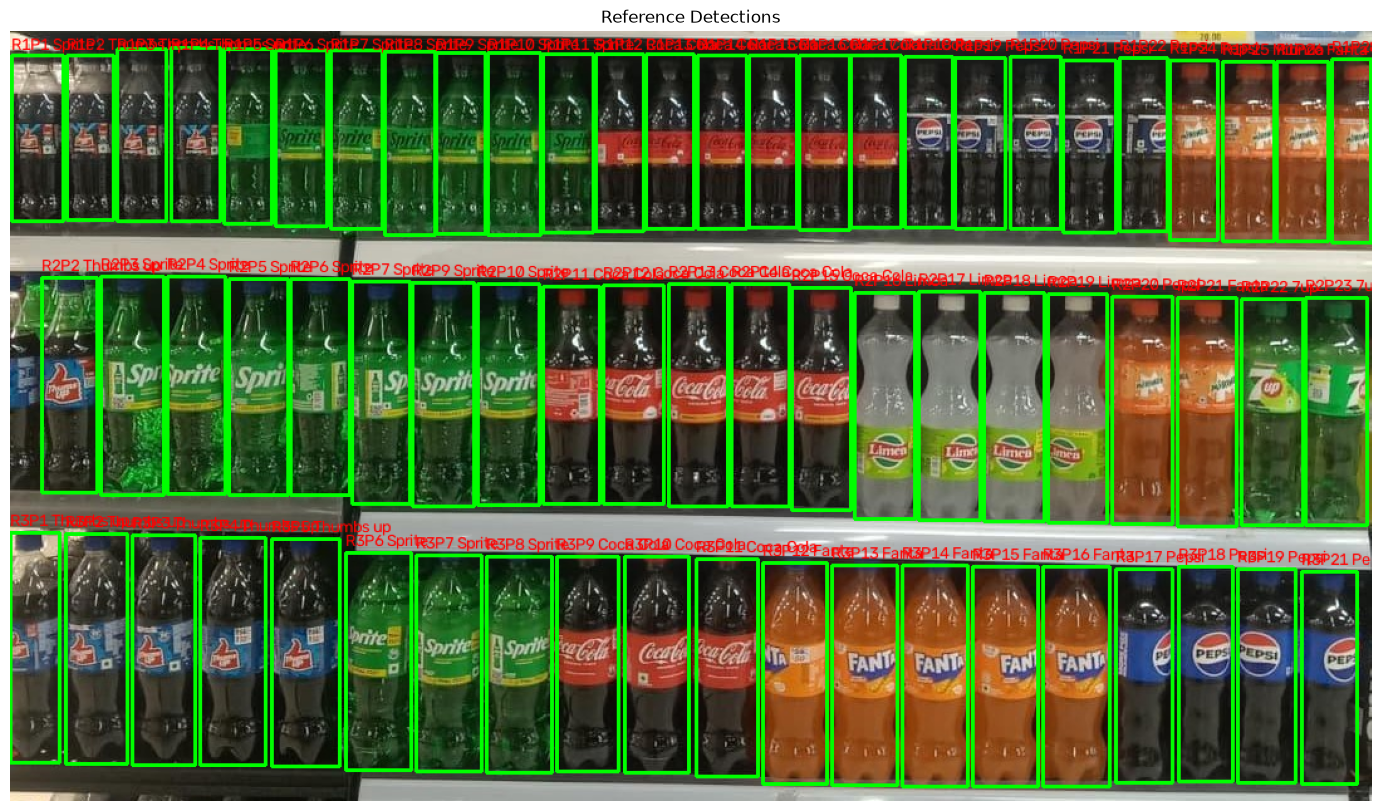

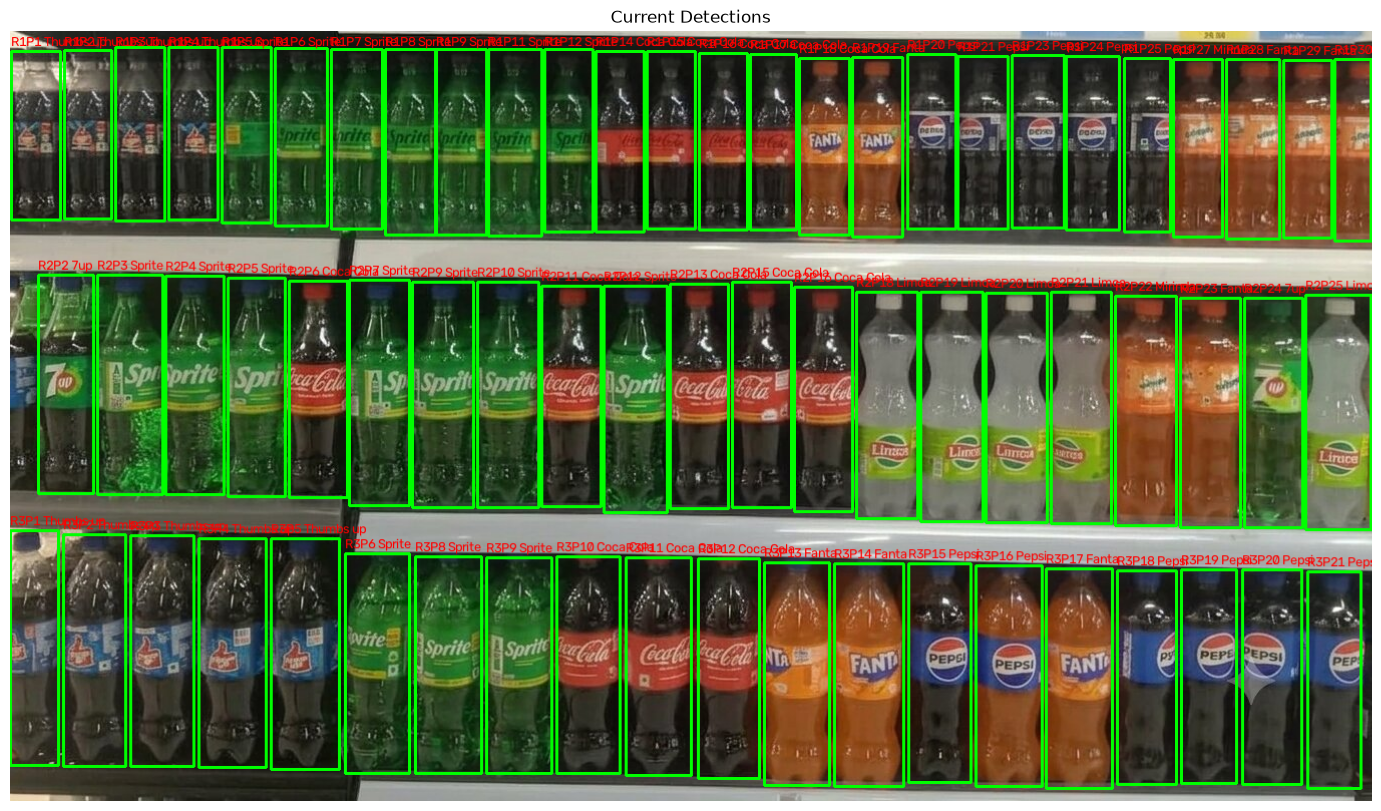

In [47]:
import cv2
import matplotlib.pyplot as plt

def draw_slots(image_path, slots, title):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for slot in slots:

        x1, y1, x2, y2 = map(int, slot["bbox"])

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

        product = slot.get("product", slot.get("expected_product", "Unknown"))

        text = f'R{slot["row"]}P{slot["position"]} {product}'

        cv2.putText(
            img,
            text,
            (x1, max(15, y1-5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255,0,0),
            1,
            cv2.LINE_AA
        )

    plt.figure(figsize=(20,10))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


draw_slots(
    "reference_images/reference_1.jpg",
    reference_slots,
    "Reference Detections"
)

draw_slots(
    CURRENT_IMAGE,
    current_slots,
    "Current Detections"
)

In [48]:
import numpy as np

N = len(reference_slots)
M = len(current_slots)

cost_matrix = np.zeros((N, M), dtype=np.float32)

ROW_PENALTY = 80
DISTANCE_WEIGHT = 1.0
SIZE_WEIGHT = 0.001

for i, ref in enumerate(reference_slots):

    rx, ry = ref["center"]

    rw = ref["bbox"][2] - ref["bbox"][0]
    rh = ref["bbox"][3] - ref["bbox"][1]
    rarea = rw * rh

    for j, cur in enumerate(current_slots):

        cx, cy = cur["center"]

        cw = cur["bbox"][2] - cur["bbox"][0]
        ch = cur["bbox"][3] - cur["bbox"][1]
        carea = cw * ch

        distance = np.sqrt((rx - cx) ** 2 + (ry - cy) ** 2)

        row_penalty = 0

        if ref["row"] != cur["row"]:
            row_penalty = ROW_PENALTY

        size_penalty = abs(rarea - carea) * SIZE_WEIGHT

        cost_matrix[i, j] = (
            DISTANCE_WEIGHT * distance
            + row_penalty
            + size_penalty
        )

print(cost_matrix.shape)

(67, 67)


In [49]:
from scipy.optimize import linear_sum_assignment

ref_idx, cur_idx = linear_sum_assignment(cost_matrix)

print(len(ref_idx))

67


In [ ]:
comparison = []

matched_reference = set()
matched_current = set()
costs = [cost_matrix[r, c] for r, c in zip(ref_idx, cur_idx)]

MAX_COST = np.percentile(costs, 95)

summary = {
    "correct": 0,
    "misplaced": 0,
    "missing": 0,
    "unexpected_product": 0
}

for r, c in zip(ref_idx, cur_idx):

    cost = cost_matrix[r, c]

    if cost > MAX_COST:
        continue

    matched_reference.add(r)
    matched_current.add(c)

    ref = reference_slots[r]
    cur = current_slots[c]

    if ref["expected_product"] == cur["product"]:

        status = "correct"
        summary["correct"] += 1

    else:

        status = "misplaced"
        summary["misplaced"] += 1

    comparison.append({

        "slot_id": ref["slot_id"],

        "expected": ref["expected_product"],

        "detected": cur["product"],

        "reference_row": ref["row"],

        "current_row": cur["row"],

        "reference_position": ref["position"],

        "current_position": cur["position"],

        "matching_cost": round(float(cost), 2),

        "status": status

    })


[{'slot_id': 1, 'expected': 'Sprite', 'detected': 'Thumbs up', 'reference_row': 1, 'current_row': 1, 'reference_position': 1, 'current_position': 1, 'matching_cost': 22.24, 'status': 'misplaced'}, {'slot_id': 2, 'expected': 'Thumbs up', 'detected': 'Thumbs up', 'reference_row': 1, 'current_row': 1, 'reference_position': 2, 'current_position': 2, 'matching_cost': 26.25, 'status': 'correct'}, {'slot_id': 3, 'expected': 'Thumbs up', 'detected': 'Thumbs up', 'reference_row': 1, 'current_row': 1, 'reference_position': 3, 'current_position': 3, 'matching_cost': 35.15, 'status': 'correct'}, {'slot_id': 4, 'expected': 'Thumbs up', 'detected': 'Thumbs up', 'reference_row': 1, 'current_row': 1, 'reference_position': 4, 'current_position': 4, 'matching_cost': 43.36, 'status': 'correct'}, {'slot_id': 5, 'expected': 'Sprite', 'detected': 'Sprite', 'reference_row': 1, 'current_row': 1, 'reference_position': 5, 'current_position': 5, 'matching_cost': 53.91, 'status': 'correct'}, {'slot_id': 6, 'expec

In [83]:
reference_slots

[{'slot_id': 1,
  'row': 1,
  'position': 1,
  'center': [21.5, 85.0],
  'bbox': [1, 19, 42, 151],
  'expected_type': 'product',
  'expected_product': 'Sprite'},
 {'slot_id': 2,
  'row': 1,
  'position': 2,
  'center': [63.5, 84.5],
  'bbox': [45, 19, 82, 150],
  'expected_type': 'product',
  'expected_product': 'Thumbs up'},
 {'slot_id': 3,
  'row': 1,
  'position': 3,
  'center': [104.5, 82.5],
  'bbox': [85, 14, 124, 151],
  'expected_type': 'product',
  'expected_product': 'Thumbs up'},
 {'slot_id': 4,
  'row': 1,
  'position': 4,
  'center': [147.5, 82.0],
  'bbox': [128, 13, 167, 151],
  'expected_type': 'product',
  'expected_product': 'Thumbs up'},
 {'slot_id': 5,
  'row': 1,
  'position': 5,
  'center': [189.0, 83.5],
  'bbox': [170, 14, 208, 153],
  'expected_type': 'product',
  'expected_product': 'Sprite'},
 {'slot_id': 6,
  'row': 1,
  'position': 6,
  'center': [231.5, 85.0],
  'bbox': [211, 15, 252, 155],
  'expected_type': 'product',
  'expected_product': 'Sprite'},
 {'

In [ ]:

for i, ref in enumerate(reference_slots):

    if i not in matched_reference:

        summary["missing"] += 1

        comparison.append({

            "slot_id": ref["slot_id"],

            "expected": ref["expected_product"],

            "status": "missing"

        })

In [60]:
for i, cur in enumerate(current_slots):

    if i not in matched_current:

        summary["unexpected_product"] += 1

        comparison.append({

            "detected": cur["product"],

            "current_row": cur["row"],

            "current_position": cur["position"],

            "status": "unexpected_product"

        })

In [61]:
import json

result = {

    "summary": summary,

    "results": comparison

}

with open("comparison.json", "w") as f:

    json.dump(result, f, indent=4)

print(json.dumps(summary, indent=4))

{
    "correct": 53,
    "misplaced": 10,
    "missing": 8,
    "unexpected_product": 4
}


In [62]:
from collections import Counter

In [64]:
reference_count = Counter()
current_count = Counter()

for slot in reference_slots:
    reference_count[slot["expected_product"]] += 1

for slot in current_slots:
    current_count[slot["product"]] += 1

In [65]:
inventory = {}

products = sorted(
    set(reference_count.keys()) |
    set(current_count.keys())
)

for product in products:

    ref = reference_count.get(product, 0)
    cur = current_count.get(product, 0)

    inventory[product] = {

        "reference": ref,
        "current": cur,
        "difference": cur - ref
    }

In [66]:
print("Inventory Summary\n")

for name, info in inventory.items():

    print(
        f"{name:15s}"
        f" Ref={info['reference']:2d}"
        f" Current={info['current']:2d}"
        f" Diff={info['difference']:3d}"
    )

Inventory Summary

7up             Ref= 2 Current= 2 Diff=  0
Coca Cola       Ref=14 Current=13 Diff= -1
Fanta           Ref= 7 Current= 8 Diff=  1
Limca           Ref= 4 Current= 5 Diff=  1
Mirinda         Ref= 1 Current= 2 Diff=  1
Pepsi           Ref=11 Current=11 Diff=  0
Sprite          Ref=18 Current=17 Diff= -1
Thumbs up       Ref=10 Current= 9 Diff= -1


In [67]:
result["inventory"] = inventory

with open("comparison.json", "w") as f:
    json.dump(result, f, indent=4)

In [68]:
print("Reference slots:", len(reference_slots))
print("Current slots:", len(current_slots))

Reference slots: 67
Current slots: 67


In [69]:
slot_ids = [slot["slot_id"] for slot in current_slots]

print("Total slot_ids:", len(slot_ids))
print("Unique slot_ids:", len(set(slot_ids)))

Total slot_ids: 67
Unique slot_ids: 67


In [70]:
pairs = [(slot["row"], slot["position"]) for slot in current_slots]

print("Total pairs:", len(pairs))
print("Unique pairs:", len(set(pairs)))

Total pairs: 67
Unique pairs: 67


Reference slots: 67


In [74]:
result

{'summary': {'correct': 53,
  'misplaced': 10,
  'missing': 8,
  'unexpected_product': 4},
 'results': [{'slot_id': 1,
   'expected': 'Sprite',
   'detected': 'Thumbs up',
   'reference_row': 1,
   'current_row': 1,
   'reference_position': 1,
   'current_position': 1,
   'matching_cost': 22.24,
   'status': 'misplaced'},
  {'slot_id': 2,
   'expected': 'Thumbs up',
   'detected': 'Thumbs up',
   'reference_row': 1,
   'current_row': 1,
   'reference_position': 2,
   'current_position': 2,
   'matching_cost': 26.25,
   'status': 'correct'},
  {'slot_id': 3,
   'expected': 'Thumbs up',
   'detected': 'Thumbs up',
   'reference_row': 1,
   'current_row': 1,
   'reference_position': 3,
   'current_position': 3,
   'matching_cost': 35.15,
   'status': 'correct'},
  {'slot_id': 4,
   'expected': 'Thumbs up',
   'detected': 'Thumbs up',
   'reference_row': 1,
   'current_row': 1,
   'reference_position': 4,
   'current_position': 4,
   'matching_cost': 43.36,
   'status': 'correct'},
  {'slo